In [ ]:
import os
import random
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms


In [ ]:
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [ ]:
!ls -l /content/drive/MyDrive/CycleGan

print("\n--- Please check the output above. If 'archive.zip' is listed, please re-run the unzip cell (cell ID: J8423PYe0Ozb) again. If it's not listed, the file is missing from this location in your Google Drive. --- ")

total 408218
-rw------- 1 root root 209001313 Dec 29 07:11  archive.zip
-rw------- 1 root root 209001313 Dec 29 17:47 'Copy of archive.zip'
drwx------ 2 root root      4096 Dec 29 18:38  models
drwx------ 2 root root      4096 Dec 29 15:55  train
drwx------ 2 root root      4096 Dec 29 15:56  val

--- Please check the output above. If 'archive.zip' is listed, please re-run the unzip cell (cell ID: J8423PYe0Ozb) again. If it's not listed, the file is missing from this location in your Google Drive. --- 


In [ ]:
!ls /content/drive/MyDrive/CycleGan


 archive.zip  'Copy of archive.zip'   models   train   val


In [ ]:
!unzip /content/drive/MyDrive/CycleGan/archive.zip -d /content/drive/MyDrive/CycleGan


Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/CycleGan/train/img/train2754.png  
  inflating: /content/drive/MyDrive/CycleGan/train/img/train2755.png  
  inflating: /content/drive/MyDrive/CycleGan/train/img/train2756.png  
  inflating: /content/drive/MyDrive/CycleGan/train/img/train2757.png  
  inflating: /content/drive/MyDrive/CycleGan/train/img/train2758.png  
  inflating: /content/drive/MyDrive/CycleGan/train/img/train2759.png  
  inflating: /content/drive/MyDrive/CycleGan/train/img/train276.png  
  inflating: /content/drive/MyDrive/CycleGan/train/img/train2760.png  
  inflating: /content/drive/MyDrive/CycleGan/train/img/train2761.png  
  inflating: /content/drive/MyDrive/CycleGan/train/img/train2762.png  
  inflating: /content/drive/MyDrive/CycleGan/train/img/train2763.png  
  inflating: /content/drive/MyDrive/CycleGan/train/img/train2764.png  
  inflating: /content/drive/MyDrive/CycleGan/train/img/train2765.png  
  inflating: /content/drive

In [ ]:
dataroot = '/content/drive/MyDrive/CycleGan'


In [ ]:

import glob


class PairedDataset(Dataset):
    def __init__(self, img_path, lbl_path, transform=None):#constructor method to initialize the dataset
        self.transform = transform # stores img transformations

        # Get all files in both folders
        img_files = glob.glob(os.path.join(img_path, "*.*"))#uses globe module to find all files within that directory
        lbl_files = glob.glob(os.path.join(lbl_path, "*.*"))

        # Build a dict by filename (without extension)
        img_dict = {os.path.splitext(os.path.basename(f))[0]: f for f in img_files} #cretaes a dictionary where keys are filenames of img & vals are full paths
        lbl_dict = {os.path.splitext(os.path.basename(f))[0]: f for f in lbl_files}

        # Keep only files that exist in both folders
        common_files = sorted(set(img_dict.keys()) & set(lbl_dict.keys())) #find common files b/w img and labels(forms pairs)

        self.img_files = [img_dict[f] for f in common_files] #stores there full paths
        self.lbl_files = [lbl_dict[f] for f in common_files]

        print(f"Found {len(self.img_files)} paired images")

    def __len__(self): #dataset subclasses:returning the total no of all the paired images
        return len(self.img_files)

    def __getitem__(self, idx): #retreives a single item from the dataset
        img_A = Image.open(self.img_files[idx]).convert("RGB") #rgb format is the targeted img for pix2pix model
        img_B = Image.open(self.lbl_files[idx]).convert("RGB")

        if self.transform:#condition for checking whether transformation sequence was provided during init
            img_A = self.transform(img_A) #img A==>target[images]
            img_B = self.transform(img_B) #imgB==>input[labels]

        return img_A, img_B


In [ ]:
transform = transforms.Compose([ #this defines the seq of img transformations to be applied to both data
    transforms.Resize((256,256), interpolation=Image.BICUBIC),#resize:inputimg==>256*256 pixels{[0,255]==>[0.0'1.0]} interpolation to enhance qlt.
    transforms.ToTensor(),#convert image==>pytorch float tensor
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)) #normalizes tensor image with mean & standard deviation {pixel values[0.0]->[-1,1]}
])
#defining "transform" to to eacj img pair:
lbl_path = r"/content/drive/MyDrive/CycleGan/train/label"   # inputs
img_path = r"/content/drive/MyDrive/CycleGan/train/img"    # targets

dataset = PairedDataset(img_path, lbl_path, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=True)

Found 2975 paired images


In [ ]:
class UNetGenerator(nn.Module):#generator network oy GAN
    def __init__(self, in_channels=3, out_channels=3):#constructor sets uo the layers of network
        super().__init__()

        def down(in_c, out_c, norm=True):#creates downsampling block for encoder.
            layers = [nn.Conv2d(in_c, out_c, 4, 2, 1)]
            if norm:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2))
            return nn.Sequential(*layers)

        def up(in_c, out_c, dropout=False):#cretaes upsampling block for decoder.
            layers = [
                nn.ConvTranspose2d(in_c, out_c, 4, 2, 1),
                nn.BatchNorm2d(out_c),
                nn.ReLU()
            ]
            if dropout:
                layers.append(nn.Dropout(0.5))
            return nn.Sequential(*layers)

        # Encoder==>
        self.d1 = down(in_channels, 64, norm=False)
        self.d2 = down(64, 128)
        self.d3 = down(128, 256)
        self.d4 = down(256, 512)

        # Decoder
        self.u1 = up(512, 256)
        self.u2 = up(512, 128)
        self.u3 = up(256, 64)
        self.u4 = nn.Sequential(
            nn.ConvTranspose2d(128, out_channels, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.d1(x)
        d2 = self.d2(d1)
        d3 = self.d3(d2)
        d4 = self.d4(d3)

        u1 = self.u1(d4)
        u2 = self.u2(torch.cat([u1, d3], dim=1))
        u3 = self.u3(torch.cat([u2, d2], dim=1))
        out = self.u4(torch.cat([u3, d1], dim=1))

        return out


In [ ]:
class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels * 2, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 1, 4, 1, 1)
        )

    def forward(self, input_img, target_img):
        x = torch.cat([input_img, target_img], dim=1)
        return self.net(x)


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

G = UNetGenerator().to(device)
D = PatchDiscriminator().to(device)

criterion_gan = nn.BCEWithLogitsLoss()  # or MSELoss
criterion_l1 = nn.L1Loss()


opt_G = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
# Get one batch from dataloader
real_A, real_B = next(iter(dataloader))

# Move to device
real_A = real_A.to(device)
real_B = real_B.to(device)

# Forward pass
fake_B = G(real_A)

print("real_A shape:", real_A.shape)
print("real_B shape:", real_B.shape)
print("fake_B shape:", fake_B.shape)


real_A shape: torch.Size([4, 3, 256, 256])
real_B shape: torch.Size([4, 3, 256, 256])
fake_B shape: torch.Size([4, 3, 256, 256])


Streaming output truncated to the last 5000 lines.
Epoch [74/80]  Loss_D: 0.0034  Loss_G: 17.5971
Epoch [74/80]  Loss_D: 0.0026  Loss_G: 17.7871
Epoch [74/80]  Loss_D: 0.0081  Loss_G: 15.6492
Epoch [74/80]  Loss_D: 0.0037  Loss_G: 20.0420
Epoch [74/80]  Loss_D: 0.0037  Loss_G: 18.4028
Epoch [74/80]  Loss_D: 0.0812  Loss_G: 13.2425
Epoch [74/80]  Loss_D: 0.0266  Loss_G: 16.5232
Epoch [74/80]  Loss_D: 0.0435  Loss_G: 14.6763
Epoch [74/80]  Loss_D: 0.0140  Loss_G: 13.8332
Epoch [74/80]  Loss_D: 0.0007  Loss_G: 22.6617
Epoch [74/80]  Loss_D: 0.0193  Loss_G: 16.0285
Epoch [74/80]  Loss_D: 0.0483  Loss_G: 16.9299
Epoch [74/80]  Loss_D: 0.0173  Loss_G: 13.4228
Epoch [74/80]  Loss_D: 0.0123  Loss_G: 14.9648
Epoch [74/80]  Loss_D: 0.0199  Loss_G: 13.8500
Epoch [74/80]  Loss_D: 0.0078  Loss_G: 16.2479
Epoch [74/80]  Loss_D: 0.0143  Loss_G: 14.2127
Epoch [74/80]  Loss_D: 0.0034  Loss_G: 19.0327
Epoch [74/80]  Loss_D: 0.0181  Loss_G: 14.2699
Epoch [74/80]  Loss_D: 0.0436  Loss_G: 13.1374
Epoch [74

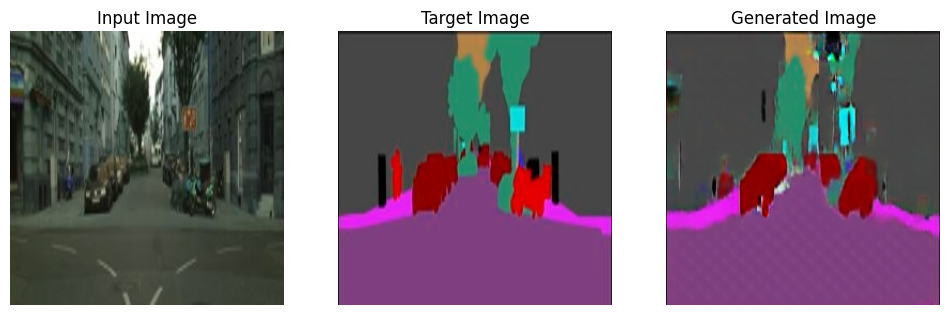

In [ ]:
for epoch in range(80):
    for real_A, real_B in dataloader:
        real_A = real_A.to(device)
        real_B = real_B.to(device)

        # --------------------
        # Train Discriminator
        # --------------------
        # Train Discriminator
        # --------------------
        opt_D.zero_grad()

        pred_real = D(real_A, real_B)
        loss_D_real = criterion_gan(pred_real, torch.ones_like(pred_real))

        fake_B = G(real_A)
        pred_fake = D(real_A, fake_B.detach())
        loss_D_fake = criterion_gan(pred_fake, torch.zeros_like(pred_fake)) #calculates gan loss for fake imgs

        loss_D = (loss_D_real + loss_D_fake) * 0.5 #total loss= avg of real and fake losses
        loss_D.backward() #computes the gradient of lossD wrt discriminators parameter
        opt_D.step() #updates the genreators weights

        # --------------------
        # Train Generator
        # --------------------
        opt_G.zero_grad()

        pred_fake = D(real_A, fake_B) #fake B==>generated images
        loss_G_GAN = criterion_gan(pred_fake, torch.ones_like(pred_fake))
        loss_G_L1 = criterion_l1(fake_B, real_B)

        loss_G = loss_G_GAN + 100 * loss_G_L1
        loss_G.backward()
        opt_G.step()
        print(f"Epoch [{epoch+1}/80]  Loss_D: {loss_D.item():.4f}  Loss_G: {loss_G.item():.4f}")




def tensor_to_image(tensor):
    tensor = tensor.detach().cpu()
    tensor = (tensor + 1) / 2
    tensor = tensor.clamp(0, 1)
    return tensor.permute(1, 2, 0).numpy()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Input Image")
plt.imshow(tensor_to_image(real_A[0]))
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Target Image")
plt.imshow(tensor_to_image(real_B[0]))
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Generated Image")
plt.imshow(tensor_to_image(fake_B[0]))
plt.axis("off")

plt.show()
